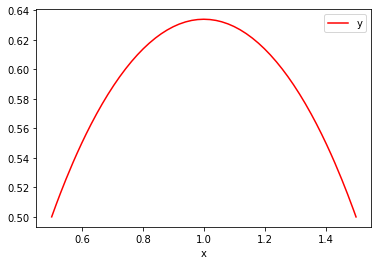

In [9]:
import sys
sys.path.append("../../")

#
# TO BE USED WITH godot/card2D_no_physics
#
import math

from lib.data.dataplot import *
from lib.system.cart import *
from lib.system.controllers import *
from lib.system.trajectory import *
from lib.system.polar import *
from lib.dds.dds import *
from lib.utils.time import *
from lib.utils.geometry import *

class CircularTrajectory:
    
    def __init__(self, trajectory_radius, trajectory_angle, vmax, acc, dec):
        self.trajectory_angle = trajectory_angle
        self.trajectory_radius = trajectory_radius
        self.trajectory_length = trajectory_angle * trajectory_radius
        self.virtual_robot = VirtualRobot(self.trajectory_length, vmax, acc, dec)
        self.x_start = 0
        self.y_start = 0
        self.theta_start = 0
        
    def set_initial_pose(self, x, y, th):
        self.x_start = x
        self.y_start = y
        self.theta_start = th

    def evaluate(self, delta_t):
        self.virtual_robot.evaluate(delta_t)
        alpha_t = self.virtual_robot.position() / self.trajectory_radius
        x = self.trajectory_radius * math.cos(math.pi/2 - alpha_t)
        y = self.trajectory_radius * math.sin(math.pi/2 - alpha_t) - self.trajectory_radius
        (x, y) = rototranslate(x, y, self.x_start, self.y_start, self.theta_start)
        return (x,y)
    
dds = DDS()
dds.start()

dds.subscribe(['tick'])

tdp = DataPlotter()
tdp.set_x("x")
tdp.add_y("y","y")


circle = CircularTrajectory( 1.0, math.radians(60),
                            1.0, # vmax
                            3.0,  # acc
                            3.0)  # dec

circle.set_initial_pose(0.5, 0.5, math.radians(30))

t = Time()
t.start()

while t.get() < 3:
    dds.wait('tick')

    delta_t = t.elapsed()
    (x, y) = circle.evaluate(delta_t)
    
    dds.publish('X', x, DDS.DDS_TYPE_FLOAT)
    dds.publish('Y', y, DDS.DDS_TYPE_FLOAT)
    dds.publish('Theta', 0, DDS.DDS_TYPE_FLOAT)

    
    tdp.append_x(x)
    tdp.append_y("y", y)
    
tdp.plot()

dds.stop()
